In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv", )
pd.set_option('display.max_columns', None)

# Set display option to show float values in standard notation
pd.set_option('display.float_format', lambda x: '%.3f' % x)

display(df.head())
display(df['Supplier_ID'].value_counts())

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer City,Customer Country,Customer Id,Customer Segment,Customer State,Customer Zipcode,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,Order_Date,Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping_Date,Shipping Mode,Post_Order_Action,Transportation_Cost,Lead_Time,Supplier_ID
0,DEBIT,3,4,91.250,314.640,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,20755,Consumer,PR,725.000,Fitness,18.251,-66.037,Pacific Asia,Bekasi,Indonesia,20755,2018-01-31 22:56:00,77202,1360,13.110,0.040,180517,327.750,0.290,1,327.750,314.640,91.250,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,Smart watch,327.750,0,2018-02-03 22:56:00,Standard Class,NaN,23.642,6,sup001
1,TRANSFER,5,4,-249.090,311.360,Late delivery,1,Sporting Goods,Caguas,Puerto Rico,19492,Consumer,PR,725.000,Fitness,18.279,-66.037,Pacific Asia,Bikaner,India,19492,2018-01-13 12:27:00,75939,1360,16.390,0.050,179254,327.750,-0.800,1,327.750,311.360,-249.090,South Asia,Rajastán,PENDING,NaN,1360,73,Smart watch,327.750,0,2018-01-18 12:27:00,Standard Class,NaN,18.305,10,sup004
2,CASH,4,4,-247.780,309.720,Shipping on time,0,Sporting Goods,San Jose,EE. UU.,19491,Consumer,CA,95125.000,Fitness,37.292,-121.881,Pacific Asia,Bikaner,India,19491,2018-01-13 12:06:00,75938,1360,18.030,0.060,179253,327.750,-0.800,1,327.750,309.720,-247.780,South Asia,Rajastán,CLOSED,NaN,1360,73,Smart watch,327.750,0,2018-01-17 12:06:00,Standard Class,NaN,21.521,8,sup004
3,DEBIT,3,4,22.860,304.810,Advance shipping,0,Sporting Goods,Los Angeles,EE. UU.,19490,Home Office,CA,90027.000,Fitness,34.126,-118.291,Pacific Asia,Townsville,Australia,19490,2018-01-13 11:45:00,75937,1360,22.940,0.070,179252,327.750,0.080,1,327.750,304.810,22.860,Oceania,Queensland,COMPLETE,NaN,1360,73,Smart watch,327.750,0,2018-01-16 11:45:00,Standard Class,NaN,21.390,6,sup002
4,PAYMENT,2,4,134.210,298.250,Advance shipping,0,Sporting Goods,Caguas,Puerto Rico,19489,Corporate,PR,725.000,Fitness,18.254,-66.037,Pacific Asia,Townsville,Australia,19489,2018-01-13 11:24:00,75936,1360,29.500,0.090,179251,327.750,0.450,1,327.750,298.250,134.210,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.750,0,2018-01-15 11:24:00,Standard Class,NaN,26.172,4,sup001


Supplier_ID
sup003    54182
sup004    45260
sup002    36015
sup005    26997
sup001    18065
Name: count, dtype: int64

In [2]:

supplier_df=df.groupby(['Supplier_ID']).agg({
    'Transportation_Cost':'sum',
    'Lead_Time':'mean',
    'Late_delivery_risk':'sum',
    'Sales':'sum',
    'Order Profit Per Order':'sum'
})
# Add the count of occurrences for each supplier
order_counts = df.groupby('Supplier_ID').size()
supplier_df['Order_Count'] = order_counts
supplier_df = supplier_df.rename(columns={'Transportation_Cost':'Total_Transportation_Cost','Late_delivery_risk':'Total_Late_Deliveries',
                                          'Sales':'Total_Sales','Order Profit Per Order':'Total_Profit','Lead_Time':'Avg_Lead_Time'})
supplier_df['Late_delivery_risk'] = supplier_df['Total_Late_Deliveries'] / supplier_df['Order_Count']
supplier_df['Avg_Transportation_Cost']=supplier_df['Total_Transportation_Cost']/supplier_df['Order_Count']
# Calculate on-time delivery rate
supplier_df['On_Time_Delivery_Rate'] = 1 - supplier_df['Late_delivery_risk']

supplier_df['Total_On_Time_Deliveries'] = supplier_df['Order_Count']-supplier_df['Total_Late_Deliveries']

display(supplier_df.head())

,Total_Transportation_Cost,Avg_Lead_Time,Total_Late_Deliveries,Total_Sales,Total_Profit,Order_Count,Late_delivery_risk,Avg_Transportation_Cost,On_Time_Delivery_Rate,Total_On_Time_Deliveries
Supplier_ID,,,,,,,,,,
sup001,246767.623,6.986,9945,3661680.960,394629.490,18065,0.551,13.660,0.449,8120
sup002,494724.213,6.954,19643,7335813.290,790640.372,36015,0.545,13.737,0.455,16372
sup003,746855.143,6.983,29708,11081666.291,1174694.150,54182,0.548,13.784,0.452,24474
sup004,621660.349,6.958,24741,9228008.807,1000616.781,45260,0.547,13.735,0.453,20519
sup005,369300.395,6.973,14940,5477565.666,606322.180,26997,0.553,13.679,0.447,12057


In [3]:
new_order_names = [
    'Total_Transportation_Cost',
    'Avg_Transportation_Cost',
    'Avg_Lead_Time',
    'Total_Sales',
    'Total_Profit',
    'Order_Count',
    'Total_Late_Deliveries',
    'Total_On_Time_Deliveries',
    'Late_delivery_risk',
    'On_Time_Delivery_Rate',
]
supplier_df = supplier_df[new_order_names]

supplier_df.head()

,Total_Transportation_Cost,Avg_Transportation_Cost,Avg_Lead_Time,Total_Sales,Total_Profit,Order_Count,Total_Late_Deliveries,Total_On_Time_Deliveries,Late_delivery_risk,On_Time_Delivery_Rate
Supplier_ID,,,,,,,,,,
sup001,246767.623,13.660,6.986,3661680.960,394629.490,18065,9945,8120,0.551,0.449
sup002,494724.213,13.737,6.954,7335813.290,790640.372,36015,19643,16372,0.545,0.455
sup003,746855.143,13.784,6.983,11081666.291,1174694.150,54182,29708,24474,0.548,0.452
sup004,621660.349,13.735,6.958,9228008.807,1000616.781,45260,24741,20519,0.547,0.453
sup005,369300.395,13.679,6.973,5477565.666,606322.180,26997,14940,12057,0.553,0.447


<Figure size 1200x800 with 0 Axes>

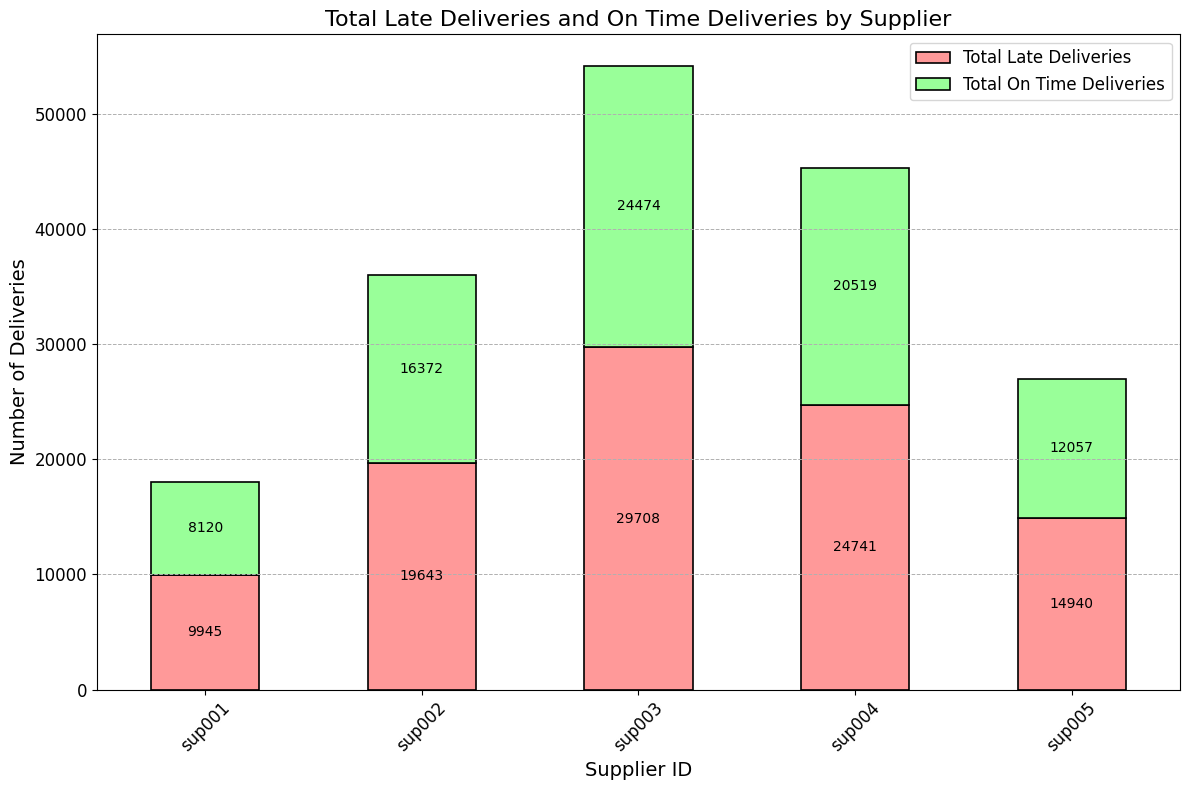

In [4]:
# Plotting
plt.figure(figsize=(12, 8))
bar_plot = supplier_df[['Total_Late_Deliveries', 'Total_On_Time_Deliveries']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 8),
    color=['#FF9999', '#99FF99'],
    edgecolor='black',
    linewidth=1.2
)

# Customization
plt.title('Total Late Deliveries and On Time Deliveries by Supplier', fontsize=16)
plt.xlabel('Supplier ID', fontsize=14)
plt.ylabel('Number of Deliveries', fontsize=14)
plt.legend(['Total Late Deliveries', 'Total On Time Deliveries'], fontsize=12)
plt.xticks(rotation=45, fontsize=12)
plt.yticks(fontsize=12)

# Add grid lines
plt.grid(axis='y', linestyle='--', linewidth=0.7)

# Add value labels
for container in bar_plot.containers:
    bar_plot.bar_label(container, label_type='center', fontsize=10, color='black')

# Show plot
plt.tight_layout()
plt.show()

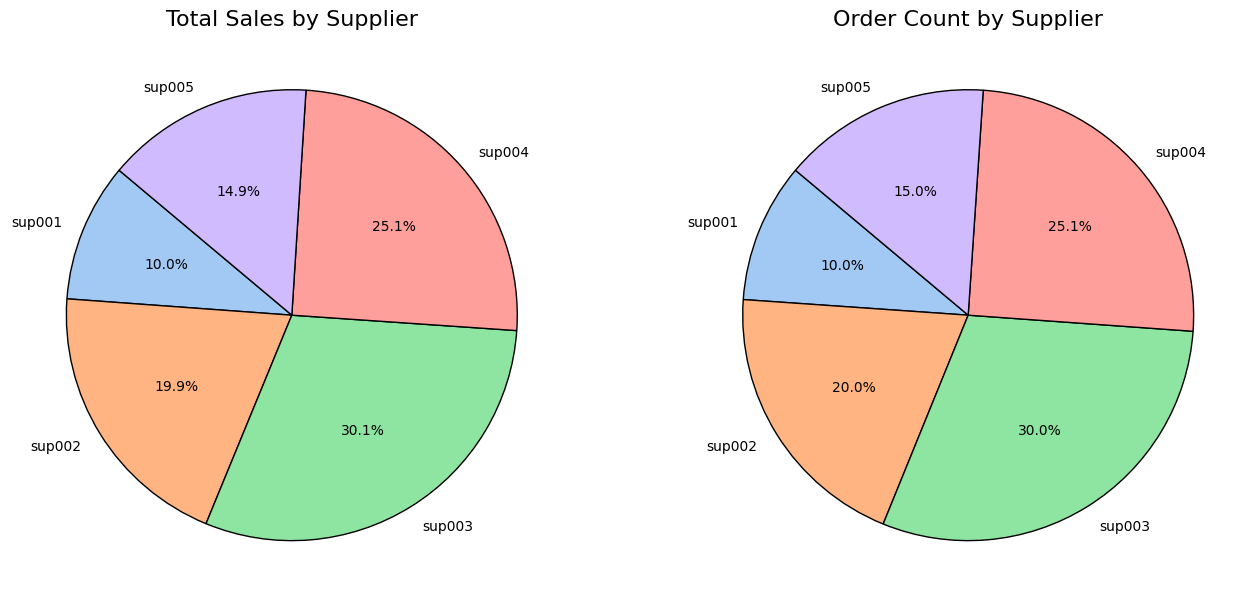

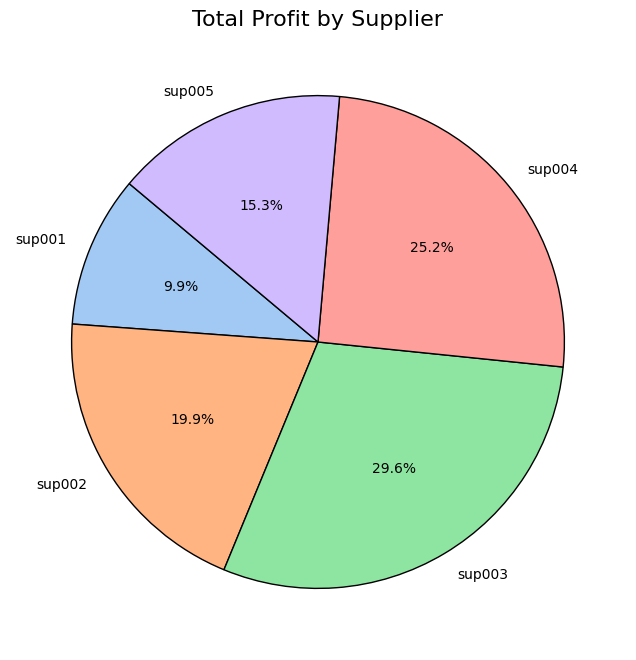

<Figure size 640x480 with 0 Axes>

In [5]:
# Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Pie chart for Total Sales
colors = sns.color_palette('pastel')[0:5]
ax1.pie(supplier_df['Total_Sales'], labels=supplier_df.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
ax1.set_title('Total Sales by Supplier', fontsize=16)

# Pie chart for Order Count
ax2.pie(supplier_df['Order_Count'], labels=supplier_df.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
ax2.set_title('Order Count by Supplier', fontsize=16)

#Pie chart for Total Profit
plt.figure(figsize=(12, 8))
colors = sns.color_palette('pastel')[0:5]
plt.pie(supplier_df['Total_Profit'], labels=supplier_df.index, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops={'edgecolor': 'black'})
plt.title('Total Profit by Supplier', fontsize=16)
plt.show()

# Customization
for ax in [ax1, ax2]:
    for text in ax.texts:
        text.set_fontsize(12)

plt.tight_layout()
plt.show()

## **Suggestions**
All suppliers have a very high late risk rate of about 55% So It is advised to look for better suppliers.